In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_curve



In [263]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [264]:
print("İlk 5 satır:")
df.head()


İlk 5 satır:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [265]:
df.drop("customerID", axis=1, inplace=True)

print("Veri setinin boyutu:", df.shape[0], "satır ve", df.shape[1], "sütun")

print("\nVeri seti hakkında bilgi:")
print(df.info())

print("\nEksik değerler:")
print(df.isnull().sum())

print("Duplicate kayıtlar:")
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.shape[0])

print("Veri Seti İstatistikleri:")
print(df.describe())



Veri setinin boyutu: 7043 satır ve 20 sütun

Veri seti hakkında bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  

In [266]:
churn_counts = df['Churn'].value_counts()
print(f"\nChurn Yok (No): {churn_counts['No']:,} (%{churn_counts['No']/len(df)*100:.1f})")
print(f"Churn Var (Yes): {churn_counts['Yes']:,} (%{churn_counts['Yes']/len(df)*100:.1f})")


Churn Yok (No): 5,174 (%73.5)
Churn Var (Yes): 1,869 (%26.5)


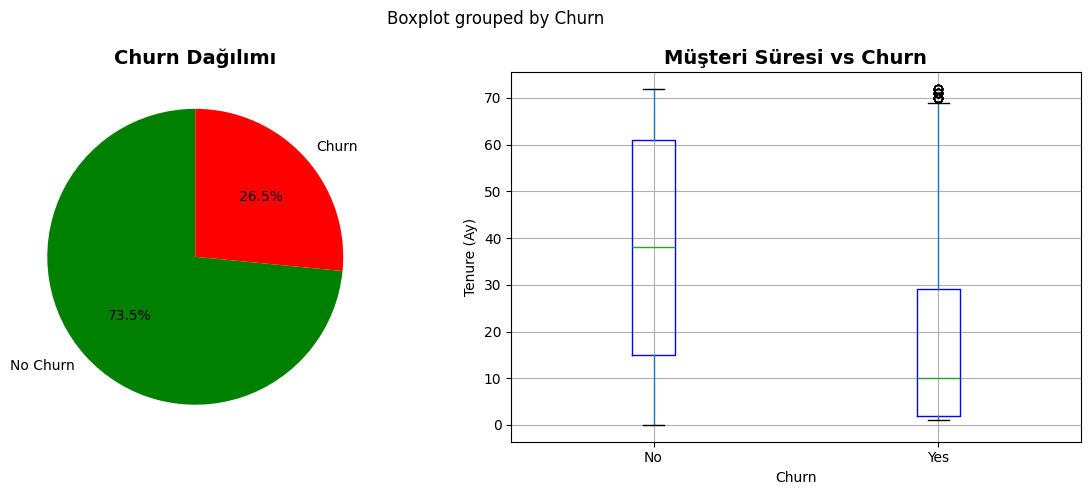

In [267]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], 
            autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[0].set_title('Churn Dağılımı', fontweight='bold', fontsize=14)

df.boxplot(column='tenure', by='Churn', ax=axes[1], 
           boxprops=dict(color='blue'))
axes[1].set_title('Müşteri Süresi vs Churn', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (Ay)')

plt.tight_layout()
plt.show()

In [268]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nan_count = df['TotalCharges'].isnull().sum()
print(f"TotalCharges NaN sayısı: {nan_count}")
print(f"Bu müşterilerin tenure değerleri:")
print(df[df['TotalCharges'].isnull()]['tenure'].values)

df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

print(f"Kontrol (ilk 3 NaN olan):")
print(df[df['tenure'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges']].head(3))

TotalCharges NaN sayısı: 11
Bu müşterilerin tenure değerleri:
[0 0 0 0 0 0 0 0 0 0 0]
Kontrol (ilk 3 NaN olan):
     tenure  MonthlyCharges  TotalCharges
488       0           52.55           0.0
753       0           20.25           0.0
936       0           80.85           0.0


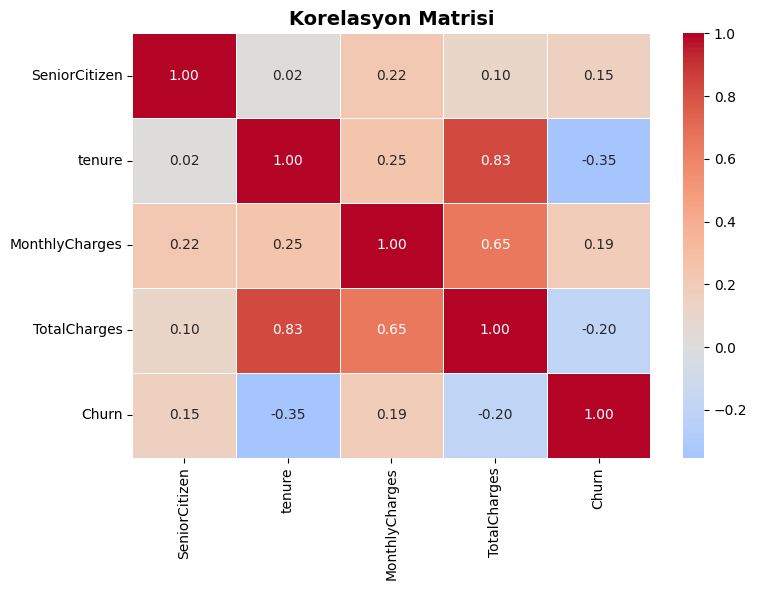

In [269]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [270]:
object_cols = df.select_dtypes(include='object').columns
print(f"Object sütunlar: {object_cols}")

Object sütunlar: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [271]:
binary_cols=[]
category_cols=[]

for col in object_cols:
    unique_vals = df[col].dropna().astype(str).str.strip().unique()
    print(f"\n{col}: {unique_vals}")
    
    if len(unique_vals) == 2:
        if set(unique_vals) == {'Yes', 'No'}:
            binary_cols.append(col)
        else:
            category_cols.append(col)
    else:
        category_cols.append(col)
print("SINIFLAMA SONUÇLARI")
print("------------------")
print(f"Binary (Yes/No): {binary_cols}")
print(f"Categorical (One-Hot): {category_cols}")
        
for col in binary_cols:
    df[col]=(df[col]=='Yes').astype(int)
print(f"{len(binary_cols)} binary sütun encode edildi!")

    
df=pd.get_dummies(df, columns=category_cols, drop_first=True, dtype=int)    
print(f"{len(category_cols)} categorical sütun encode edildi!")
print(f"Final shape: {df.shape}")
print(f"Örnek sütunlar: {df.columns[:15].tolist()}")    


gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
SINIFLAMA SONUÇLARI
------------------
Binary (Yes/No): ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Categorical (One-Hot): ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'P

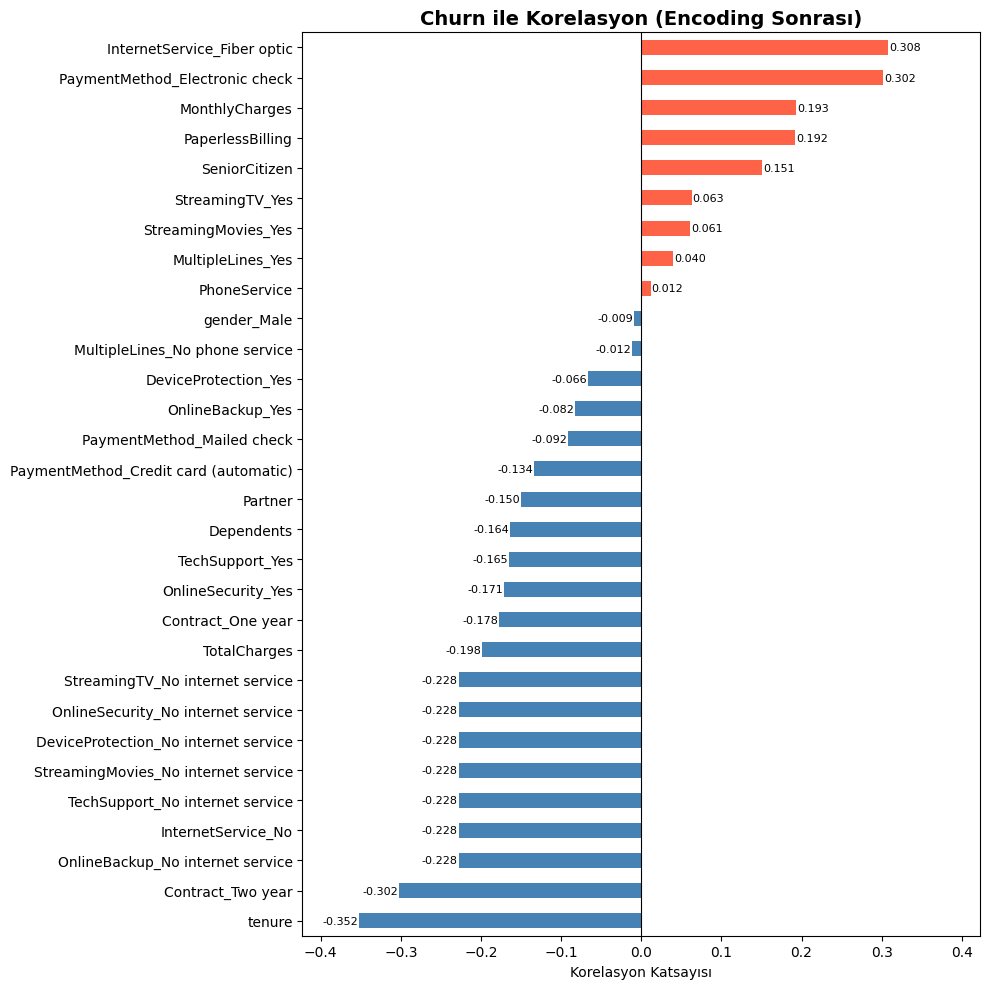

In [272]:
churn_corr = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(10, 10))
colors = ['tomato' if x > 0 else 'steelblue' for x in churn_corr]
churn_corr.plot(kind='barh', color=colors)
plt.title("Churn ile Korelasyon (Encoding Sonrası)", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Korelasyon Katsayısı")
margin = max(abs(churn_corr.min()), abs(churn_corr.max())) * 1.2
plt.xlim(-margin, margin)
for i, v in enumerate(churn_corr):
    plt.text(v + (0.001 if v >= 0 else -0.001), i,
             f'{v:.3f}', va='center',
             ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

In [273]:
X=df.drop('Churn', axis=1)
y=df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lr=Pipeline([
    ('scaler', StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced'))]
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")


              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[749 286]
 [ 80 294]]
ROC AUC Score: 0.8414


In [274]:
print("── LR Threshold Analizi ──")
thresholds = [0.3, 0.4, 0.5, 0.6]
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test,y_pred_t):.2f}, "
          f"Recall={recall_score(y_test,y_pred_t):.2f}, "
          f"F1={f1_score(y_test,y_pred_t):.2f}")

── LR Threshold Analizi ──
Threshold 0.3: Precision=0.43, Recall=0.93, F1=0.59
Threshold 0.4: Precision=0.46, Recall=0.87, F1=0.61
Threshold 0.5: Precision=0.51, Recall=0.79, F1=0.62
Threshold 0.6: Precision=0.54, Recall=0.71, F1=0.61


In [275]:
xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # class_weight karşılığı
        random_state=42,
        n_estimators=300,
        eval_metric='auc',
    ))
])

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("── XGBoost Threshold Analizi ──")
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test,y_pred_t):.2f}, "
          f"Recall={recall_score(y_test,y_pred_t):.2f}, "
          f"F1={f1_score(y_test,y_pred_t):.2f}")

              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1035
           1       0.55      0.61      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.76      0.77      1409

[[845 190]
 [145 229]]
ROC AUC Score: 0.8076
── XGBoost Threshold Analizi ──
Threshold 0.3: Precision=0.51, Recall=0.72, F1=0.60
Threshold 0.4: Precision=0.54, Recall=0.67, F1=0.60
Threshold 0.5: Precision=0.55, Recall=0.61, F1=0.58
Threshold 0.6: Precision=0.56, Recall=0.56, F1=0.56


In [276]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

print("── Random Forest Threshold Analizi ──")
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test,y_pred_t):.2f}, "
          f"Recall={recall_score(y_test,y_pred_t):.2f}, "
          f"F1={f1_score(y_test,y_pred_t):.2f}")

ROC AUC Score: 0.8253
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

── Random Forest Threshold Analizi ──
Threshold 0.3: Precision=0.53, Recall=0.72, F1=0.61
Threshold 0.4: Precision=0.58, Recall=0.63, F1=0.60
Threshold 0.5: Precision=0.63, Recall=0.49, F1=0.55
Threshold 0.6: Precision=0.68, Recall=0.38, F1=0.49


In [277]:
def kfold_evaluate(name, model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    scores = cross_validate(
        model, X, y, cv=skf,
        scoring={
            'roc_auc': 'roc_auc',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        return_train_score=True
    )
    
    print(f"\n{'='*50}")
    print(f"MODEL: {name} ({cv}-Fold CV)")
    print(f"  ROC AUC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"  Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
    print(f"  Recall   : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
    print(f"  F1       : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"  Train AUC: {scores['train_roc_auc'].mean():.4f} (overfit kontrolü)")
    
    return scores

kfold_evaluate("Logistic Regression", lr, X, y)
kfold_evaluate("XGBoost", xgb, X, y)
kfold_evaluate("Random Forest", rf, X, y)


MODEL: Logistic Regression (5-Fold CV)
  ROC AUC  : 0.8450 ± 0.0134
  Precision: 0.5131 ± 0.0068
  Recall   : 0.8036 ± 0.0162
  F1       : 0.6263 ± 0.0092
  Train AUC: 0.8486 (overfit kontrolü)

MODEL: XGBoost (5-Fold CV)
  ROC AUC  : 0.8080 ± 0.0113
  Precision: 0.5425 ± 0.0137
  Recall   : 0.5875 ± 0.0134
  F1       : 0.5641 ± 0.0132
  Train AUC: 0.9996 (overfit kontrolü)

MODEL: Random Forest (5-Fold CV)
  ROC AUC  : 0.8251 ± 0.0118
  Precision: 0.6324 ± 0.0143
  Recall   : 0.4767 ± 0.0264
  F1       : 0.5435 ± 0.0222
  Train AUC: 0.9998 (overfit kontrolü)


{'fit_time': array([0.78172421, 0.81362867, 0.77398634, 0.79524541, 0.78258681]),
 'score_time': array([0.23215628, 0.3464129 , 0.19379234, 0.28136253, 0.26582122]),
 'test_roc_auc': array([0.83614663, 0.82253739, 0.83898577, 0.80594345, 0.82205805]),
 'train_roc_auc': array([0.9997432 , 0.99995847, 0.99989576, 0.99984795, 0.99976621]),
 'test_precision': array([0.6462585 , 0.6369863 , 0.64768683, 0.61423221, 0.61678832]),
 'train_precision': array([0.99334664, 0.99136786, 0.9953271 , 0.99401198, 0.99203716]),
 'test_recall': array([0.50802139, 0.4973262 , 0.48663102, 0.43967828, 0.45187166]),
 'train_recall': array([0.99866221, 0.99866221, 0.99732441, 0.9986631 , 1.        ]),
 'test_f1': array([0.56886228, 0.55855856, 0.55572519, 0.5125    , 0.52160494]),
 'train_f1': array([0.99599733, 0.99500167, 0.99632476, 0.99633211, 0.99600266])}

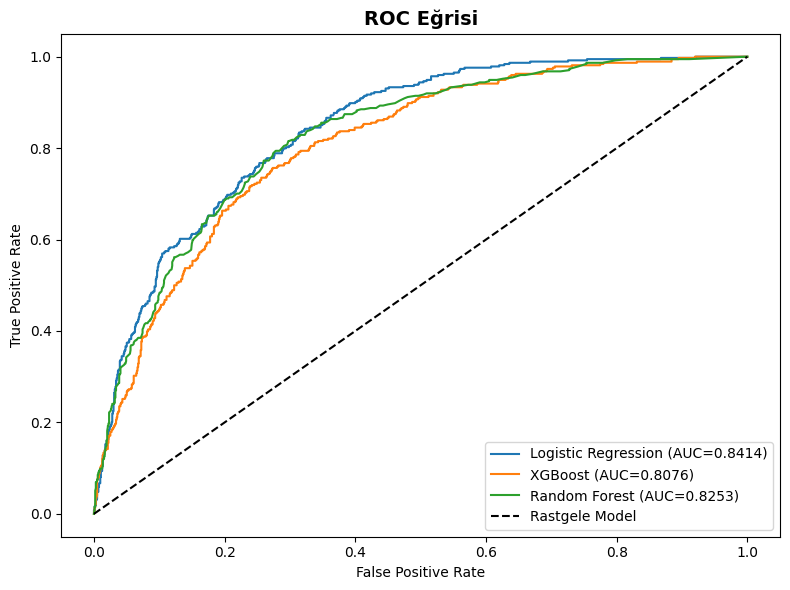

In [278]:
plt.figure(figsize=(8, 6))

for name, y_proba in [("Logistic Regression", y_proba_lr), 
                       ("XGBoost", y_proba_xgb), 
                       ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label="Rastgele Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

              Model  ROC AUC  Precision  Recall     F1
Logistic Regression   0.8414     0.5069  0.7861 0.6164
            XGBoost   0.8076     0.5465  0.6123 0.5776
      Random Forest   0.8253     0.6329  0.4840 0.5485


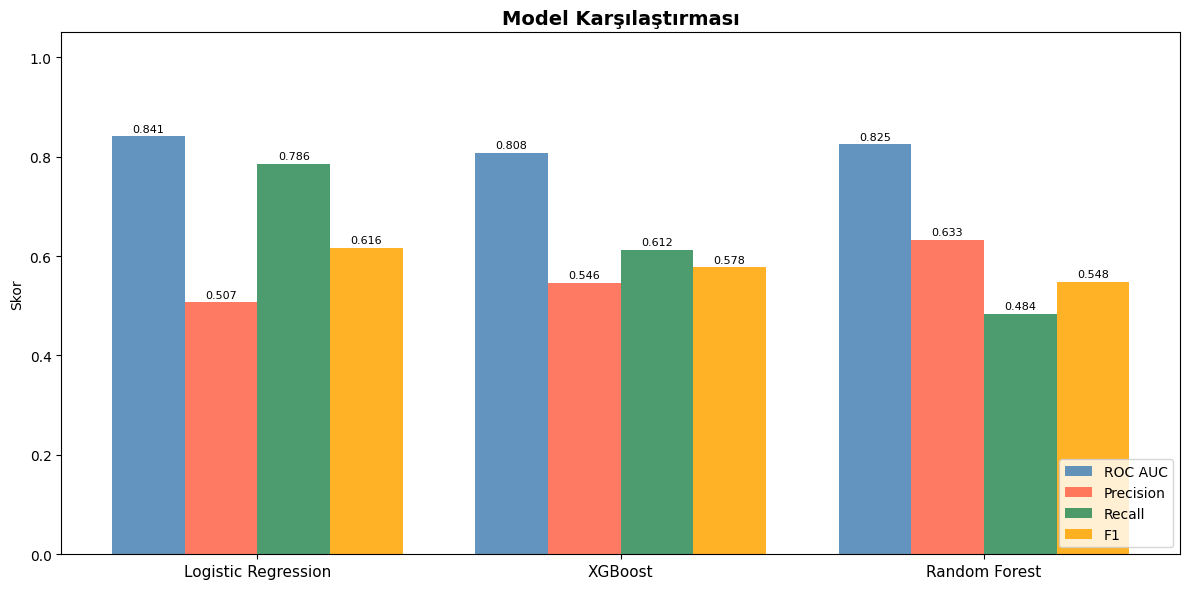

In [279]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'ROC AUC': [roc_auc_score(y_test, y_proba_lr),
                roc_auc_score(y_test, y_proba_xgb),
                roc_auc_score(y_test, y_proba_rf)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_xgb),
                  precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_xgb),
               recall_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_lr),
           f1_score(y_test, y_pred_xgb),
           f1_score(y_test, y_pred_rf)]
}).round(4)

print(results.to_string(index=False))

results_melted = results.melt(id_vars='Model', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(12, 6))
x = np.arange(len(results['Model']))
width = 0.2
metriks = ['ROC AUC', 'Precision', 'Recall', 'F1']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for i, (metrik, renk) in enumerate(zip(metriks, colors)):
    deger = results[metrik]
    bars = plt.bar(x + i*width, deger, width, label=metrik, color=renk, alpha=0.85)
    for bar, val in zip(bars, deger):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x + width*1.5, results['Model'], fontsize=11)
plt.ylim(0, 1.05)
plt.ylabel("Skor")
plt.title("Model Karşılaştırması", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

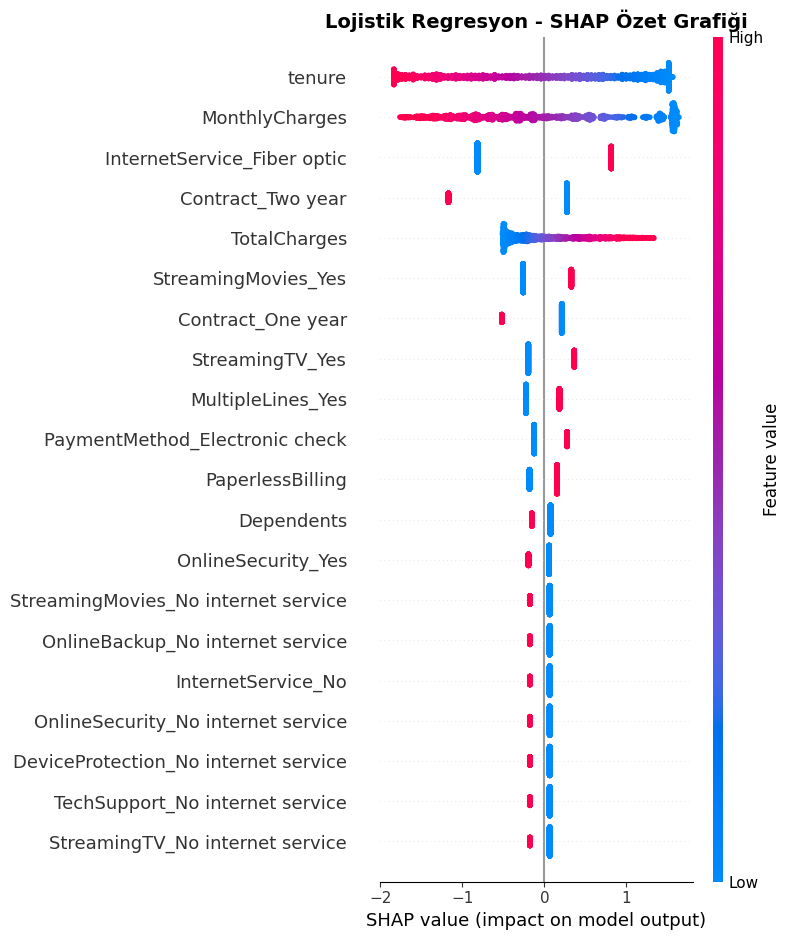

In [280]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

lr_model = lr.named_steps['model']
scaler = lr.named_steps['scaler']

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)


explainer = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
plt.title("Lojistik Regresyon - SHAP Özet Grafiği", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.tight_layout()
plt.show()